In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from torch_geometric.data import Data
import torch
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Parse SMILES into molecular graphs

In [2]:
df = pd.read_csv('mol_datasets/panasonic.csv')
df = df.drop(columns=["Unnamed: 0"])
print(len(df))
df.head()

434


,SMILES,ERE,HRE,rings,fused,bridged,F,S,O,Si,N
0,FC=1C(F)=C(F)C2=CC3=C(SC4=C3SC5=CC=6C=CC=CC6C=...,0.21,0.13,6.0,5.0,0.0,4.0,2.0,0.0,0.0,0.0
1,S1C=2C=CC=3C=CC=CC3C2C=4SC=5C=CC=6C=CC=CC6C5C14,0.21,0.20,6.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0
2,S1C2=CC(=CC=C2C=3SC=4C=C(C=CC4C13)CCCCCCCC)CCC...,0.29,0.25,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
3,S1C=C2C=C3SC4=CC=CC=C4C3=CC2=C1,0.22,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0
4,S1C=CC=2C=C3C=C4C=CSC4=CC3=CC12,0.21,0.11,4.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0


62


/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/rdkit/Chem/Draw/IPythonConsole.py:365: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


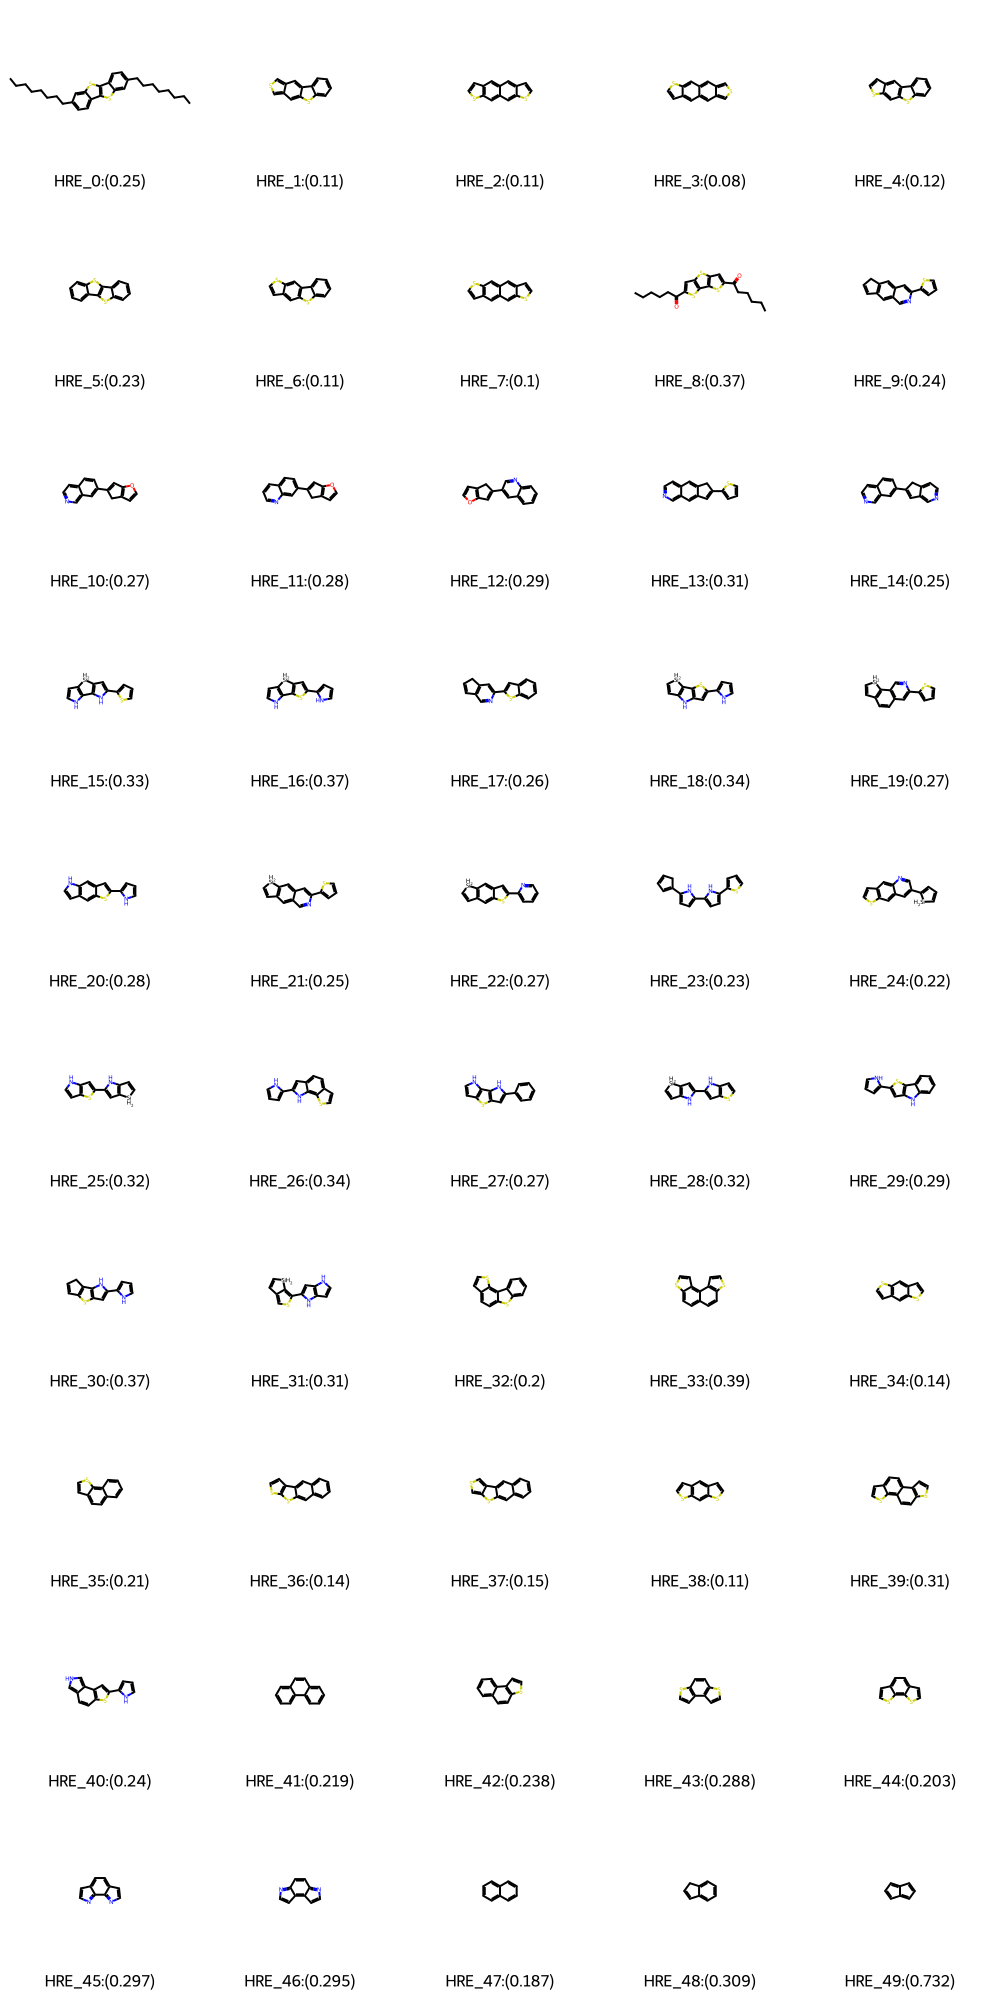

In [3]:
df_4_rings = df[df['rings']<4.1]
print(len(df_4_rings))
mols = [Chem.MolFromSmiles(s) for s in df_4_rings['SMILES'].values]
hre_list = [round(i,3) for i in list(df_4_rings['HRE'].values)]
labels = [f"HRE_{i}:({hre_list[i]})" for i in range(len(df_4_rings))]
img = Draw.MolsToGridImage(mols[:], molsPerRow=5, subImgSize=(200,200), legends=labels)
img

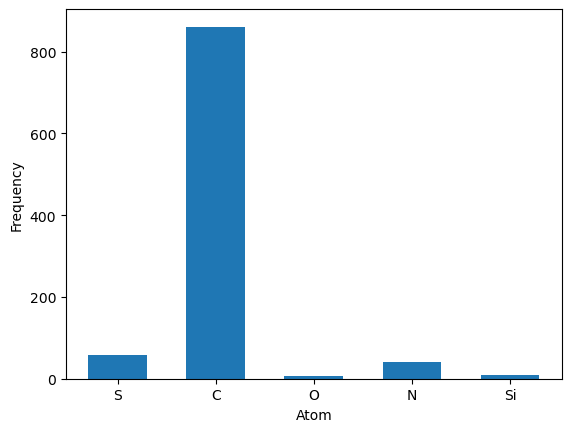

In [4]:
from collections import Counter
all_atoms = []
for smi in df_4_rings['SMILES'].values:
    mol = Chem.MolFromSmiles(smi)
    if mol:  
        for atom in mol.GetAtoms():
            all_atoms.append(atom.GetSymbol())

counts = Counter(all_atoms)
labels = list(counts.keys())
values = list(counts.values())
plt.bar(labels, values, align='center', width=0.6)
plt.xlabel("Atom")
plt.ylabel("Frequency")
plt.show()

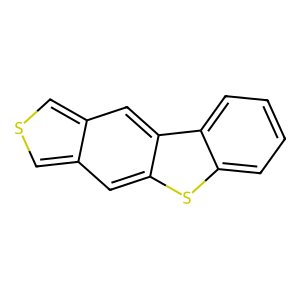

In [5]:
# Example usage
smiles = list(df_4_rings['SMILES'].values)[1]
hre = list(df_4_rings['HRE'].values)[1]

mol = Chem.MolFromSmiles(smiles)
img = Draw.MolsToGridImage([mol], molsPerRow=1, subImgSize=(300,300))
img

In [ ]:
import torch
from torch_geometric.data import InMemoryDataset, Data
from rdkit import Chem

# Define mappings
node_mapping = {0: "C", 1: "S", 2: "O", 3: "N", 4: "Si"}
edge_mapping = {
    0: Chem.BondType.SINGLE,
    1: Chem.BondType.DOUBLE,
    2: Chem.BondType.TRIPLE,
    3: Chem.BondType.AROMATIC
}

def smiles_to_ptcfm(smiles, energy):
    mol = Chem.MolFromSmiles(smiles)

    # Atom codes → one-hot
    atom_types = ["C", "S","O","N","Si"]
    x = []
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 6: code = 0   # Carbon
        elif atom.GetAtomicNum() == 16: code = 1
        elif atom.GetAtomicNum() == 8: code = 2
        elif atom.GetAtomicNum() == 7: code = 3
        elif atom.GetAtomicNum() == 14: code = 4
        # else: code = 0                         
        one_hot = [0]*len(atom_types)
        one_hot[code] = 1
        x.append(one_hot)
    x = torch.tensor(x, dtype=torch.float)

    # Connectivity + same dummy edge_attr for all edges
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [(i, j), (j, i)]
        edge_attr += [[1], [1]]   # identical feature for every edge
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    y = torch.tensor([float(energy)], dtype=torch.float)

    return Data(edge_index=edge_index, x=x, edge_attr=edge_attr, y=y)

class SMILESDataset(InMemoryDataset):
    def __init__(self, smiles_list, energies, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        graphs = [smiles_to_ptcfm(s, e) for s, e in zip(smiles_list, energies)]
        self.data, self.slices = self.collate(graphs)

In [7]:
dataset = SMILESDataset(smiles_list=list(df_4_rings['SMILES'].values), energies=list(df_4_rings['HRE'].values))

In [8]:
dataset[0]

Data(x=[32, 5], edge_index=[2, 70], edge_attr=[70, 1], y=[1])

In [9]:
import qek.data.graphs as qek_graphs
from pathlib import Path
import qek.data.extractors as qek_extractors

compiler = qek_graphs.PTCFMCompiler()

extractor = qek_extractors.QutipExtractor(
    path=Path("mol_datasets/processed/saved_data.json"), # save the data
    compiler=compiler
)
extractor.add_graphs(graphs=dataset)
compiled = extractor.compile()
display("Compiled %s sequences" % (len(compiled), ))

graph # 1 is not embeddable, skipping
imported 61 graphs


/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)
/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/pulser/register/register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, pr

'Compiled 61 sequences'

In [11]:
# On our test computer, the practical limit is around 10 qubits - according to Pasqal
# do not set the max_qubits above 16. The terminal is automatically killed due to computational overheads

max_qubits = 18
processed_dataset = extractor.run(max_qubits=max_qubits).processed_data

# it does not seem to take our target values
# moreover, the extractor is designed to handle molecules with four rings

display("Extracted features from %s samples"% (len(processed_dataset), ))

Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (25 > 18), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (19 > 18), skipping
Graph <built-in function id> exceeds the qubit limit specified in QutipExtractor (20 > 18), skipping
processed data saved to mol_datasets/processed/saved_data.json


'Extracted features from 58 samples'

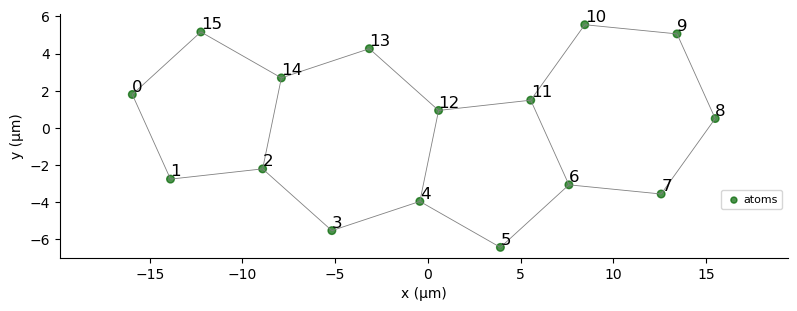

In [12]:
example = processed_dataset[0]
example.draw_register()

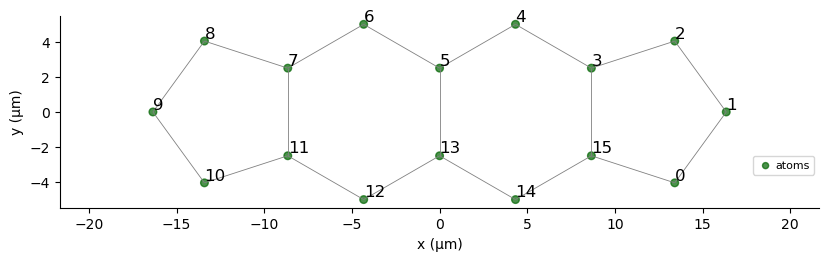

In [30]:
example = processed_dataset[1]
example.draw_register()

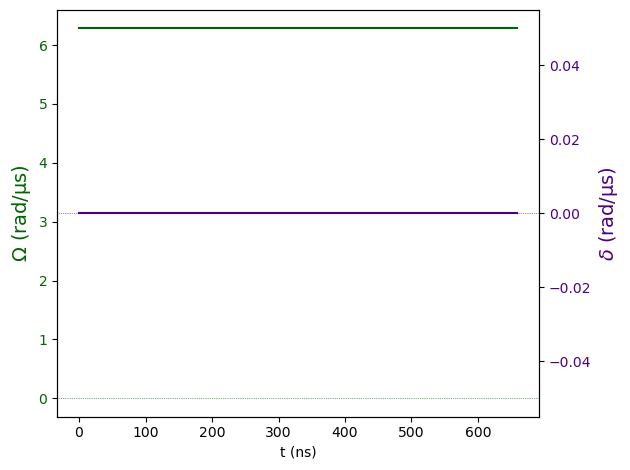

In [13]:
example.draw_pulse()

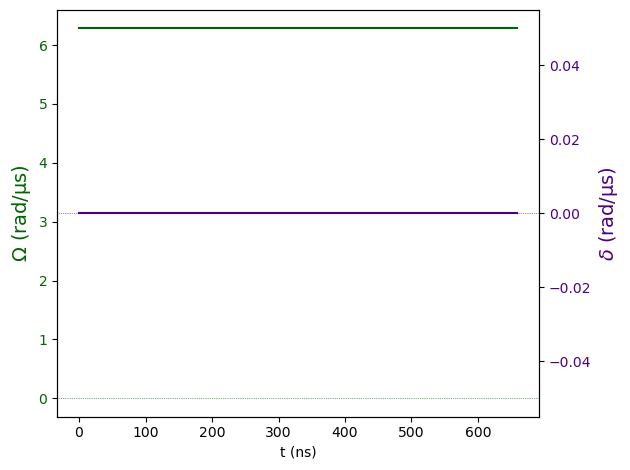

In [14]:
processed_dataset[1].draw_pulse() # same purses for all graphs?

In [15]:
display(example.state_dict)
print(f"Total number of samples: {sum(example.state_dict.values())}")

{'0000100000000000': 17,
 '0000001000000000': 17,
 '0000000100100100': 1,
 '0001001000000000': 9,
 '0001000000001010': 3,
 '0000000000000000': 75,
 '0100001001000010': 1,
 '0000000101000000': 8,
 '0100001000101001': 1,
 '0010100000000100': 4,
 '0000000100000000': 9,
 '0010000000000001': 11,
 '0000010000000000': 22,
 '0001000000001000': 12,
 '0000010100010000': 5,
 '0100000000001001': 1,
 '0100000000000010': 12,
 '0001010000001000': 5,
 '0000101010000100': 2,
 '0010000000000100': 9,
 '0001000000010100': 6,
 '0000000000000001': 9,
 '0001000000000100': 12,
 '1001000100101000': 1,
 '0001000100000000': 6,
 '0101010000000001': 1,
 '0100001010100100': 1,
 '0001000000101000': 2,
 '0101010100001000': 1,
 '0010000000000010': 1,
 '0000000000100000': 14,
 '0000000000001010': 7,
 '0010010000000000': 11,
 '0001000000000001': 5,
 '0000000000101001': 1,
 '0000000000100001': 1,
 '0000010101001000': 3,
 '0100000100000000': 2,
 '0100000100101000': 1,
 '0001000000000000': 20,
 '0000010000001001': 2,
 '001

Total number of samples: 1000


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


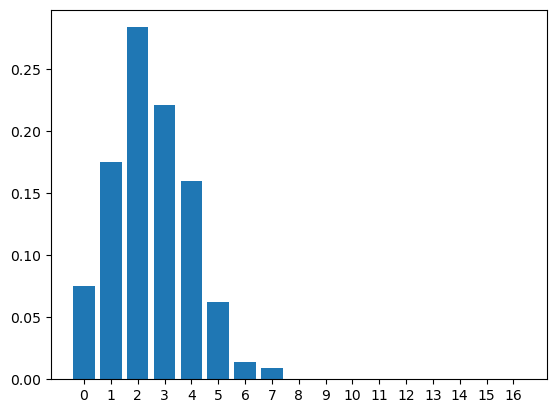

In [16]:
example.draw_excitation()

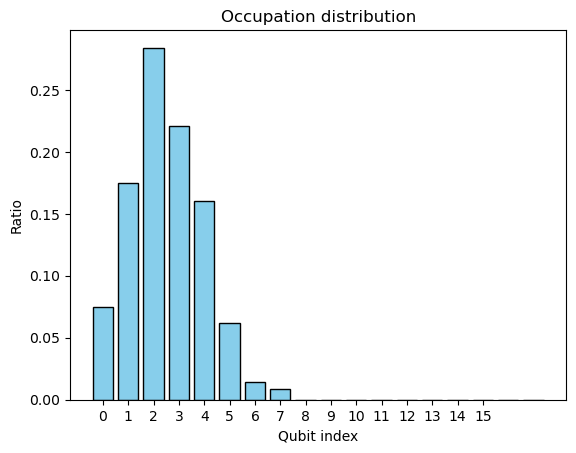

In [17]:
dist_excitation = np.zeros(max_qubits, dtype=int)

for state, weight in example.state_dict.items():
    num_up = state.count('1')
    dist_excitation[num_up] += weight

ratios = dist_excitation / dist_excitation.sum()

plt.bar(range(max_qubits), ratios, color="skyblue", edgecolor="black")
plt.xticks(range(16))
plt.xlabel("Qubit index")
plt.ylabel("Ratio")
plt.title('Occupation distribution')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from qek.kernel import QuantumEvolutionKernel as QEK
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

Kernel-based regression

In [19]:
X = [data for data in processed_dataset]  
y = [data.target for data in processed_dataset] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # remove stratify argument for regression

qek_kernel = QEK(mu=0.5)
model = SVR(kernel=qek_kernel)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.0
MAE: 0.0
R²: 1.0


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [20]:
qek_kernel = QEK(mu=0.5)
model = SVR(kernel=qek_kernel)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.0
MAE: 0.0
R²: 1.0


In [23]:
from scipy.spatial.distance import jensenshannon

max_size = max(len(data.dist_excitation()) for data in processed_dataset)
distributions = [data.dist_excitation(size=max_size) for data in processed_dataset]
y = np.array([data.target for data in processed_dataset])

# Pairwise JSD distances
n = len(distributions)
distance_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = jensenshannon(distributions[i], distributions[j])

# Convert to similarity (kernel) matrix
similarity_matrix = 1 - distance_matrix

In [24]:
similarity_matrix.shape

(58, 58)

In [25]:
# Train/test split
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size=0.4, random_state=42)

# Extract submatrices for training and testing
K_train = similarity_matrix[np.ix_(train_idx, train_idx)]
K_test = similarity_matrix[np.ix_(test_idx, train_idx)]

y_train, y_test = y[train_idx], y[test_idx]

# SVR with precomputed kernel
svr = SVR(kernel="precomputed")
svr.fit(K_train, y_train)
y_pred = svr.predict(K_test)

print("SVR with JSD kernel")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


SVR with JSD kernel
MSE: 0.0
MAE: 0.0
R²: 1.0


In [26]:
from sklearn.manifold import MDS
from sklearn.ensemble import RandomForestRegressor

# Embed distance matrix into Euclidean space
embedding = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_embedded = embedding.fit_transform(distance_matrix)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_embedded, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest with JSD embedding")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest with JSD embedding
MSE: 0.0
MAE: 0.0
R²: 1.0


/home/syj43/miniconda3/envs/chem-env/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


w/ cross validation

In [27]:
# w/ cross validation
rf = RandomForestRegressor(n_estimators=50, random_state=42)

# Cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scorers
mse_scorer = make_scorer(mean_squared_error)
mae_scorer = make_scorer(mean_absolute_error)
r2_scorer  = make_scorer(r2_score)

# Evaluate with cross-validation
mse_scores = cross_val_score(rf, X_embedded, y, cv=cv, scoring=mse_scorer)
mae_scores = cross_val_score(rf, X_embedded, y, cv=cv, scoring=mae_scorer)
r2_scores  = cross_val_score(rf, X_embedded, y, cv=cv, scoring=r2_scorer)

print("Random Forest with JSD embedding (cross‑validation)")
print("Mean MSE:", mse_scores.mean())
print("Mean MAE:", mae_scores.mean())
print("Mean R²:", r2_scores.mean())

Random Forest with JSD embedding (cross‑validation)
Mean MSE: 0.0
Mean MAE: 0.0
Mean R²: 1.0
